<a href="https://colab.research.google.com/github/vishalakshi-19/ML_Week1/blob/main/gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harpartapsingh13/student-burnout-and-dropout-risk-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-burnout-and-dropout-risk-dataset' dataset.
Path to dataset files: /kaggle/input/student-burnout-and-dropout-risk-dataset


In [3]:
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
df = pd.read_csv(os.path.join(path, csv_files[0]))

In [4]:
df.head()

,Student_ID,Age,Gender,Year_of_Study,Department,Residence_Type,Attendance_Percent,Study_Hours_Per_Day,Previous_GPA,Backlogs,...,Family_Income_Bracket,Financial_Stress_Score,Family_Support_Score,Stress_Level,Anxiety_Score,Motivation_Score,Peer_Pressure_Score,Counseling_Access,Burnout_Level,Dropout_Risk
0,STU00001,23,Female,2,Science,Hostel,93.0,4.1,7.13,2.0,...,Upper-Middle,5.5,10.0,4.0,NaN,7.0,NaN,No,Low,No
1,STU00002,20,Female,4,Engineering,Day Scholar,94.3,0.0,10.00,0.0,...,Low,3.7,4.0,5.5,5.1,9.3,2.8,Yes,Medium,Yes
2,STU00003,24,Male,2,Business,PG/Rented,61.2,2.6,8.02,0.0,...,Middle,4.8,8.1,9.0,5.2,5.7,5.4,No,High,Yes
3,STU00004,21,Female,4,Medicine,Hostel,66.9,3.1,5.34,1.0,...,Lower-Middle,7.0,6.6,2.8,4.2,5.1,3.9,No,High,Yes
4,STU00005,23,Female,1,Engineering,NaN,84.8,2.9,4.45,1.0,...,Lower-Middle,1.3,7.3,0.9,6.4,8.1,5.1,No,Low,No


In [5]:
df.sample(10)

,Student_ID,Age,Gender,Year_of_Study,Department,Residence_Type,Attendance_Percent,Study_Hours_Per_Day,Previous_GPA,Backlogs,...,Family_Income_Bracket,Financial_Stress_Score,Family_Support_Score,Stress_Level,Anxiety_Score,Motivation_Score,Peer_Pressure_Score,Counseling_Access,Burnout_Level,Dropout_Risk
568,STU00569,24,Male,2,Arts,Day Scholar,99.9,3.1,6.57,2.0,...,Upper-Middle,4.2,4.7,7.0,4.2,8.9,5.0,No,Low,Yes
83,STU00084,21,Female,4,Law,Hostel,61.6,2.1,5.98,0.0,...,High,5.2,4.8,7.1,6.9,6.0,3.3,No,High,Yes
748,STU00749,25,NaN,1,Business,Hostel,80.0,2.3,4.37,0.0,...,Middle,2.5,9.8,3.6,6.1,7.5,5.7,Yes,Low,No
274,STU00275,21,Female,1,Arts,PG/Rented,72.0,4.3,6.61,3.0,...,Low,3.1,2.1,3.3,3.1,10.0,7.6,Yes,Medium,Yes
272,STU00273,17,Male,2,Science,Day Scholar,63.0,5.2,5.50,0.0,...,High,7.9,8.2,6.1,2.6,4.9,4.9,No,Low,Yes
65,STU00066,21,Female,1,Arts,Day Scholar,75.7,1.5,NaN,0.0,...,Lower-Middle,3.2,7.3,5.5,4.2,5.1,1.8,No,Medium,Yes
644,STU00645,17,Female,4,Medicine,PG/Rented,81.0,1.3,10.00,1.0,...,Lower-Middle,7.6,4.9,5.0,4.6,7.1,6.2,No,Medium,No
482,STU00483,24,Female,4,Medicine,PG/Rented,74.2,3.9,8.52,0.0,...,Middle,6.1,4.6,5.0,1.1,4.1,1.6,No,Low,No
396,STU00397,20,Other,3,Business,PG/Rented,92.9,2.8,6.42,0.0,...,High,7.9,6.0,5.2,3.9,4.4,7.0,No,Low,No
459,STU00460,20,Female,3,Medicine,Hostel,58.5,0.9,8.84,2.0,...,Middle,0.8,5.6,5.8,6.5,3.1,3.9,No,High,Yes


In [6]:
df.shape

(800, 25)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Student_ID              800 non-null    object 
 1   Age                     800 non-null    int64  
 2   Gender                  770 non-null    object 
 3   Year_of_Study           800 non-null    int64  
 4   Department              777 non-null    object 
 5   Residence_Type          783 non-null    object 
 6   Attendance_Percent      749 non-null    float64
 7   Study_Hours_Per_Day     765 non-null    float64
 8   Previous_GPA            765 non-null    float64
 9   Backlogs                785 non-null    float64
 10  Sleep_Hours             765 non-null    float64
 11  Screen_Time_Hours       764 non-null    float64
 12  Exercise_Freq_Per_Week  800 non-null    int64  
 13  Social_Activity_Score   760 non-null    float64
 14  Part_Time_Job           775 non-null    ob

In [8]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,30
Year_of_Study,0
Department,23
Residence_Type,17
Attendance_Percent,51
Study_Hours_Per_Day,35
Previous_GPA,35
Backlogs,15


In [9]:
df.describe()

,Age,Year_of_Study,Attendance_Percent,Study_Hours_Per_Day,Previous_GPA,Backlogs,Sleep_Hours,Screen_Time_Hours,Exercise_Freq_Per_Week,Social_Activity_Score,Financial_Stress_Score,Family_Support_Score,Stress_Level,Anxiety_Score,Motivation_Score,Peer_Pressure_Score
count,800.000000,800.000000,749.000000,765.000000,765.000000,785.000000,765.000000,764.000000,800.000000,760.000000,757.000000,756.000000,751.000000,761.000000,759.000000,759.000000
mean,20.883750,2.281250,76.884246,3.158431,6.859242,0.824204,6.199869,5.432461,2.011250,4.994605,5.025892,6.419180,5.516644,4.982917,5.470751,4.484058
std,2.602153,1.105068,14.258149,1.558711,1.401110,0.939320,1.499472,2.200261,1.480325,1.961375,2.235882,2.087761,1.946800,2.105225,2.043605,1.894575
min,17.000000,1.000000,30.000000,0.000000,2.420000,0.000000,2.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000
25%,19.000000,1.000000,66.200000,2.100000,5.880000,0.000000,5.200000,3.975000,1.000000,3.600000,3.500000,5.000000,4.200000,3.500000,4.100000,3.200000
50%,21.000000,2.000000,77.400000,3.100000,6.860000,1.000000,6.300000,5.450000,2.000000,5.000000,5.000000,6.500000,5.500000,5.100000,5.400000,4.500000
75%,23.000000,3.000000,88.600000,4.200000,7.800000,1.000000,7.200000,6.925000,3.000000,6.400000,6.600000,7.900000,6.900000,6.500000,6.900000,5.700000
max,25.000000,4.000000,100.000000,8.100000,10.000000,6.000000,10.000000,12.600000,7.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,9.800000


In [10]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='count', ylabel='Gender'>

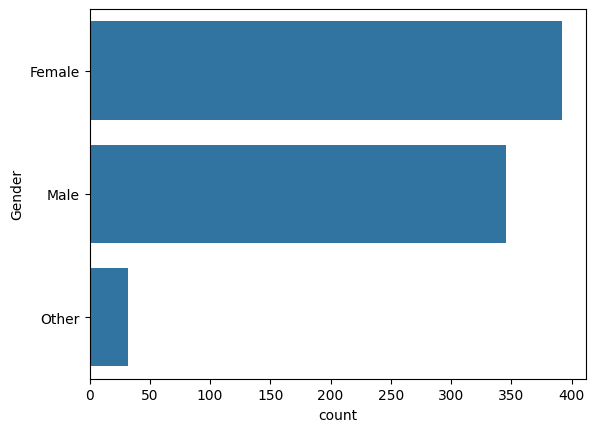

In [11]:
sns.countplot(df["Gender"])

<Axes: xlabel='Family_Income_Bracket'>

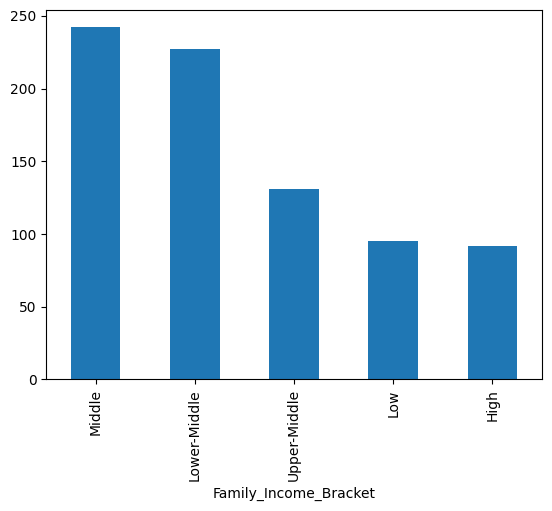

In [12]:

df["Family_Income_Bracket"].value_counts().plot(kind="bar")

<Axes: xlabel='Backlogs'>

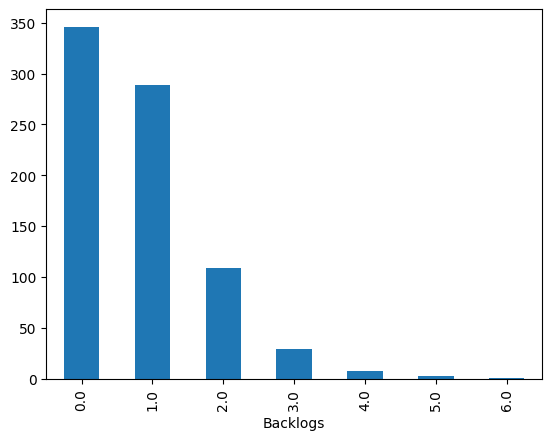

In [13]:
df["Backlogs"].value_counts().plot(kind="bar")

<Axes: xlabel='Part_Time_Job'>

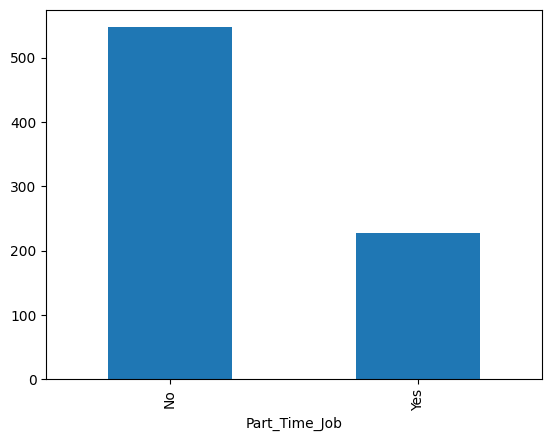

In [14]:
df["Part_Time_Job"].value_counts().plot(kind="bar")

<Axes: xlabel='Residence_Type'>

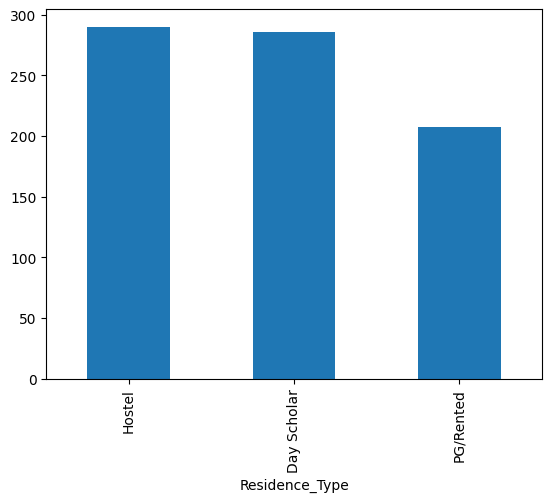

In [15]:
df["Residence_Type"].value_counts().plot(kind="bar")

<Axes: xlabel='Department'>

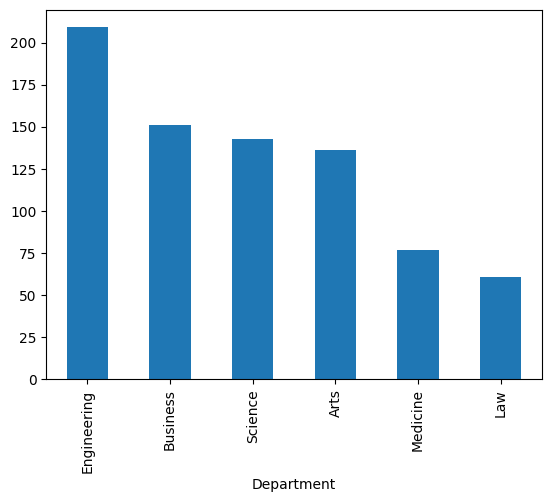

In [16]:
df["Department"].value_counts().plot(kind="bar")

<Axes: ylabel='Stress_Level'>

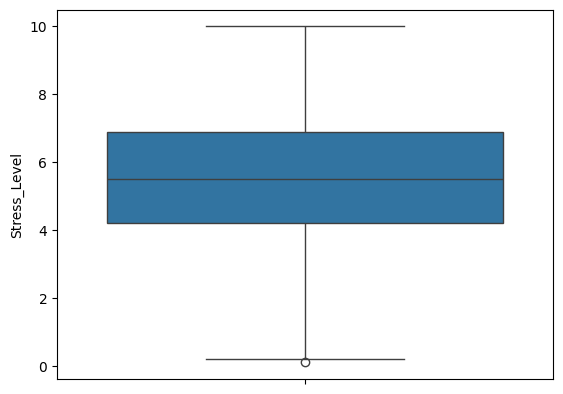

In [17]:
sns.boxplot(df["Stress_Level"])

In [18]:
df['Financial_Stress_Score'].skew()

np.float64(-0.012269716187019976)

In [19]:
from sklearn.impute import SimpleImputer

In [20]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
ohe= OneHotEncoder()

In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
# Removed: from pandas._config.config import Mode

transformer1 = ColumnTransformer(transformers=[
    ('t1', SimpleImputer(strategy='most_frequent'), ['Study_Hours_Per_Day']),
    ('t2', SimpleImputer(strategy='mean'), ["Financial_Stress_Score"]),
    ], remainder="passthrough")

In [45]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
# Removed: from pandas._config.config import Mode

transformer2 = ColumnTransformer(transformers=[
    ('t1', SimpleImputer(strategy='most_frequent'), ["Department"]),
    ('t2', SimpleImputer(strategy='most_frequent'), ["Part_Time_Job"])
], remainder="passthrough")

In [23]:
df['Social_Activity_Score'].fillna(df['Social_Activity_Score'].mean(), inplace=True)

/tmp/ipykernel_6295/2721488452.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Social_Activity_Score'].fillna(df['Social_Activity_Score'].mean(), inplace=True)


In [24]:
df['Previous_GPA'].fillna(df['Previous_GPA'].mean(), inplace=True)

/tmp/ipykernel_6295/1171247338.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Previous_GPA'].fillna(df['Previous_GPA'].mean(), inplace=True)


In [ ]:

non_null_values = df['Gender'].dropna()

# 2. Count how many missing values need to be filled
num_missing = df['Gender'].isnull().sum()

# 3. Take a random sample from non-nulls equal to the missing count
# 'replace=True' ensures you can draw enough samples if missing count > non-null count
random_samples = non_null_values.sample(n=num_missing, replace=True, random_state=42)

# 4. Align the index of the random samples with the missing data indices
random_samples.index = df[df['Gender'].isnull()].index

# 5. Fill the missing values
df.loc[df['Gender'].isnull(), 'Gender'] = random_samples

In [25]:
df['Gender'].isnull().sum()

np.int64(30)

In [46]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,30
Year_of_Study,0
Department,23
Residence_Type,17
Attendance_Percent,51
Study_Hours_Per_Day,35
Previous_GPA,0
Backlogs,15


In [27]:

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

In [29]:
x_train,x_test,y_train,y_test=train_test_split(df.drop('Dropout_Risk',axis=1),df['Dropout_Risk'],test_size=0.2,random_state=42)

In [33]:
transformer1.fit_transform(x_train)
transformer2.fit_transform(x_train)

array([['Engineering', 'No', 'STU00265', ..., 5.0, 'No', 'High'],
       ['Engineering', 'Yes', 'STU00616', ..., 4.3, 'No', 'High'],
       ['Business', 'No', 'STU00330', ..., 6.7, 'No', 'Low'],
       ...,
       ['Medicine', 'No', 'STU00271', ..., nan, 'No', 'High'],
       ['Law', 'No', 'STU00436', ..., 4.3, 'No', 'High'],
       ['Arts', 'No', 'STU00103', ..., 0.0, 'No', 'High']], dtype=object)

In [47]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,30
Year_of_Study,0
Department,23
Residence_Type,17
Attendance_Percent,51
Study_Hours_Per_Day,35
Previous_GPA,0
Backlogs,15


In [42]:
df["Attendance_Percent"].fillna(-1)

,Attendance_Percent
0,93.0
1,94.3
2,61.2
3,66.9
4,84.8
...,...
795,68.1
796,91.0
797,-1.0
798,84.9


In [34]:
transformer1.fit_transform(x_test)
transformer2.fit_transform(x_test)

array([['Engineering', 'No', 'STU00697', ..., 5.1, 'Yes', 'Low'],
       ['Medicine', 'No', 'STU00668', ..., 4.4, 'No', 'Low'],
       ['Arts', 'No', 'STU00064', ..., 3.7, 'No', 'Medium'],
       ...,
       ['Arts', 'No', 'STU00745', ..., 3.7, 'No', 'Medium'],
       ['Arts', 'No', 'STU00514', ..., 6.3, 'Yes', 'Medium'],
       ['Arts', 'No', 'STU00671', ..., 3.1, 'No', 'Low']], dtype=object)

<Axes: ylabel='count'>

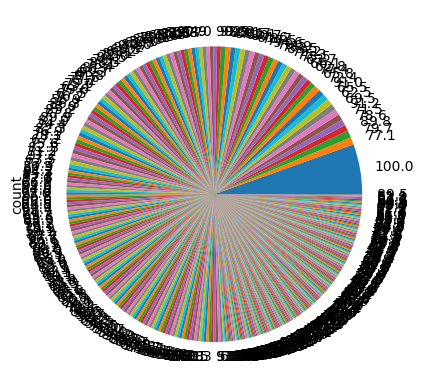

In [43]:
df["Attendance_Percent"].value_counts().plot(kind="pie")

In [48]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,30
Year_of_Study,0
Department,23
Residence_Type,17
Attendance_Percent,51
Study_Hours_Per_Day,35
Previous_GPA,0
Backlogs,15


In [52]:
import random

In [57]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Year_of_Study,0
Department,0
Residence_Type,17
Attendance_Percent,51
Study_Hours_Per_Day,35
Previous_GPA,0
Backlogs,15


In [56]:
df['Department'].fillna(df['Department'].mode()[0], inplace=True)

/tmp/ipykernel_6295/1184361446.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Department'].fillna(df['Department'].mode()[0], inplace=True)


In [55]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)

In [69]:
df['Residence_Type'].fillna("other")

,Residence_Type
0,Hostel
1,Day Scholar
2,PG/Rented
3,Hostel
4,other
...,...
795,PG/Rented
796,Hostel
797,PG/Rented
798,Day Scholar


In [59]:
df['Attendance_Percent'].fillna(-1)

,Attendance_Percent
0,93.0
1,94.3
2,61.2
3,66.9
4,84.8
...,...
795,68.1
796,91.0
797,-1.0
798,84.9


In [60]:
df['Study_Hours_Per_Day'].fillna(df['Study_Hours_Per_Day'].mean(), inplace=True)

/tmp/ipykernel_6295/3687350085.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Study_Hours_Per_Day'].fillna(df['Study_Hours_Per_Day'].mean(), inplace=True)


In [61]:
df['Backlogs'].fillna(df['Backlogs'].mode()[0], inplace=True)

/tmp/ipykernel_6295/4066857706.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Backlogs'].fillna(df['Backlogs'].mode()[0], inplace=True)


In [63]:
df['Screen_Time_Hours'].fillna(df['Screen_Time_Hours'].mean(), inplace=True)
df['Sleep_Hours'].fillna(df['Sleep_Hours'].mean(),inplace=True)
df['Anxiety_Score'].fillna(df['Anxiety_Score'].mean(),inplace=True)
df['Family_Support_Score'].fillna(df['Family_Support_Score'].mean(),inplace=True)
df['Financial_Stress_Score'].fillna(df['Financial_Stress_Score'].mean(),inplace=True)
df['Social_Activity_Score'].fillna(df['Social_Activity_Score'].mean(),inplace=True)
df['Previous_GPA'].fillna(df['Previous_GPA'].mean(),inplace=True)


/tmp/ipykernel_6295/2687425520.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Screen_Time_Hours'].fillna(df['Screen_Time_Hours'].mean(), inplace=True)
/tmp/ipykernel_6295/2687425520.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method

In [70]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Year_of_Study,0
Department,0
Residence_Type,17
Attendance_Percent,0
Study_Hours_Per_Day,0
Previous_GPA,0
Backlogs,0


In [66]:
df['Residence_Type'].fillna("missing")
df['Attendance_Percent'].fillna(df['Attendance_Percent'].mean(),inplace=True)
df['Part_Time_Job'].fillna(df['Part_Time_Job'].mode()[0],inplace=True)
df['Family_Income_Bracket'].fillna(df['Family_Income_Bracket'].mode()[0],inplace=True)
df['Stress_Level'].fillna(df['Stress_Level'].mean(),inplace=True)
df['Motivation_Score'].fillna(df['Motivation_Score'].mean(),inplace=True)
df['Peer_Pressure_Score'].fillna(df['Peer_Pressure_Score'].mean(),inplace=True)


/tmp/ipykernel_6295/2002557690.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Attendance_Percent'].fillna(df['Attendance_Percent'].mean(),inplace=True)
/tmp/ipykernel_6295/2002557690.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].metho

In [71]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Year_of_Study,0
Department,0
Residence_Type,17
Attendance_Percent,0
Study_Hours_Per_Day,0
Previous_GPA,0
Backlogs,0


In [72]:
df['Residence_Type'].fillna(df['Residence_Type'].mode()[0],inplace=True)

/tmp/ipykernel_6295/3883338041.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Residence_Type'].fillna(df['Residence_Type'].mode()[0],inplace=True)


In [73]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Year_of_Study,0
Department,0
Residence_Type,0
Attendance_Percent,0
Study_Hours_Per_Day,0
Previous_GPA,0
Backlogs,0


In [78]:
df['Dropout_Risk']

,Dropout_Risk
0,No
1,Yes
2,Yes
3,Yes
4,No
...,...
795,No
796,Yes
797,Yes
798,No


In [80]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder

In [81]:
df['Family_Income_Bracket'].unique()

array(['Upper-Middle', 'Low', 'Middle', 'Lower-Middle', 'High'],
      dtype=object)

In [82]:
oe= OrdinalEncoder(categories=[["High",'Upper-Middle','Middle','Lower-Middle','Low']])

In [85]:
x_train['Family_Income_Bracket'].fillna(x_train['Family_Income_Bracket'].mode()[0], inplace=True)
x_train['Family_Income_Bracket']=oe.fit_transform(x_train[['Family_Income_Bracket']])

/tmp/ipykernel_6295/3729674019.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_train['Family_Income_Bracket'].fillna(x_train['Family_Income_Bracket'].mode()[0], inplace=True)
